# GAMPixPy Point Source Generator Example

This notebook will walk through the proces of using the point source signal generator in the simulation framework, including writing to and reading simulation products from disk, as well as some simple analysis steps

In [1]:
from gampixpy import detector, generator, plotting, config, output

Next, some related libraries which are needed for this notebook:

In [2]:
import matplotlib.pyplot as plt
# set up matplotlib for this notebook
%matplotlib widget

import tqdm
import numpy as np

# import torch and set the default device (needed for GPU)
import torch

if torch.cuda.is_available():
    device = torch.device('cuda')
    # Set the default device to CUDA
    torch.set_default_device(device)
    print(f"Default device set to: {torch.cuda.get_device_name(device)}")
else:
    device = torch.device('cpu')
    print("CUDA is not available, using CPU")

CUDA is not available, using CPU


## Configuration
The first step in simulation is to define our detector and how it will behave. These configuration parameters are divided into three categories:

- *detector config*: defines the physical size and location of the detector volume(s).
- *physics config*: defines the physical properties of the detector material (LAr) and parameters pertaining to drift mechanics and charge yield. These parameters very rarely need to be changed, and the default is usually fine.
- *readout config*: defines the details of the anode plane e.g., pitches for coarse tiles and pixels, noise levels, thresholds, etc.
These config objects act like dictionaries. They will be used at various points by the library, so keep them handy!

After defining these, we'll use them to create a detector model.



In [3]:
# the `demo_large_pixels` readout config is nice for visualizing
# but it will often not produce enough pixel hits.
# use whichever suits your purpose!
conf = config.ConfigManager(detector_config = 'far_detector_vd',
                            #readout_config = 'demo_large_pixels',
                            readout_config = 'GAMPixD',
                            )

## We can also build one of these from a yaml file
## The configs which come along with the library are
## accessible from the `preset_[...]_configs`, but can
## also be found alongside the library code
# readout_config = config.ReadoutConfig('../../gampixpy/readout_config/GAMPixD_notruth.yaml')

detector_model = detector.DetectorModel(config_manager=conf)

## Generators
Next, we need set up a generator to produce some charge clouds of a specific profile.  Here, we'll generate point sources.  We can set our generator up to place these point sources within some specific interval in space and time (and charge!) from which each individual point source is sampled with uniform probability.

In [4]:
ps_gen = generator.PointSource(x_range = [-10, 10],
                               y_range = [-10, 10],
                               z_range = [-10, 10],
                               t_range = [0, 0],
                               q_range = [1e6, 1e8],
                              )

event_data = ps_gen.get_sample()
event_meta = ps_gen.get_meta()

## Simulation

Once we have configured our detector model and read in some input data, simulation is easy!

In [5]:
detector_model.drift(event_data)
detector_model.readout(event_data)

## This can also be done as a single step
# detector_model.simulate(event_data)

simulating coarse grid...
coarse time series built
coarse hit finding...
simulating fine grid...
pixel time series built
pixel hit finding...
found 2 coarse tile hits
found 21 pixel hits


## Visualization
Now, let's take a look at the results of the simulation:

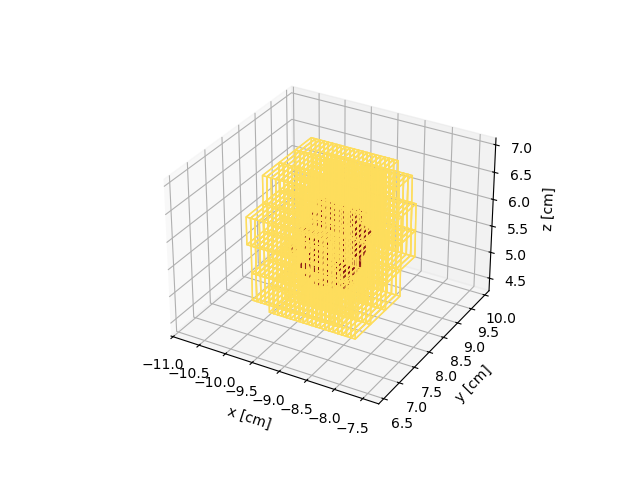

In [6]:
evd = plotting.EventDisplay(event_data, config_manager=conf)

# A few of these calls are commented out to make it easier to see
# on github. Un-comment a few to see all of the simulation products!

#evd.plot_raw_track()
evd.plot_drifted_track()

#evd.plot_drift_volumes()

#evd.plot_coarse_tile_measurement() # plot tile hits

evd.plot_pixel_measurement() # plot pixel hits

evd.show()

## File Output
To record the simulation outputs, we use the included output management system

In [7]:
!rm test_output.h5
om = output.OutputManager('test_output.h5', config_manager=conf)
om.add_entry(event_data, event_meta)

## Batch Simulation

In order to simulate a few events and save them all to a single output file, we simply nest these steps into a loop:

In [8]:
# clean the old output
!rm test_output.h5
# re-initialize the output manager
om = output.OutputManager('test_output.h5', config_manager=conf)

# here, we'll do 10 events
n_events = 10

# let's add a nice progress bar
import tqdm
for i in tqdm.tqdm(range(n_events)):
    # generate a new point source object
    event_data = ps_gen.get_sample()
    event_meta = ps_gen.get_meta()

    # use `verbose = False` to suppress the info messages
    detector_model.simulate(event_data, verbose = False)

    # write this to the output file
    om.add_entry(event_data, event_meta)

100%|██████████████████████████████████████████████████████████| 10/10 [00:05<00:00,  1.80it/s]


## Reading Simulation Output from Disk

For most cases, we can use a built-in output parser object to read from output files.  Here, each event will have only a single point source, which will have label `0`

In [9]:
from gampixpy import analysis
op = analysis.OutputParser('./test_output.h5')

pixels, tiles, meta = op.get_data(event_id = 0, label = 0)

print(pixels.dtype)
print(pixels[0])

[('event id', '<u4'), ('tile trigger id', '<u4'), ('pixel tpc', '<u4'), ('pixel x', '<f4'), ('pixel y', '<f4'), ('trig z', '<f4'), ('trig t', '<f4'), ('waveform', '<f4', (20,)), ('attribution', '<f4', (20, 3)), ('label', '<i4', (3,))]
(0, 0, 0, -1050.25, 9.25, 321.89938, 2010.4462, [-32.11987, 637.3648, -35.54343, 707.5154, -55.839684, 4051.7466, 4839.8286, 8793.666, 5439.816, 5397.54, 2722.982, 652.339, 1334.6957, 20.355303, -8.3325815, -65.18451, 28.696012, 90.858444, 43.59736, -33.723072], [[0.0, 0.0, 0.0], [1.0, 0.0, 0.0], [0.0, 0.0, 0.0], [1.0, 0.0, 0.0], [0.0, 0.0, 0.0], [1.0, 0.0, 0.0], [1.0, 0.0, 0.0], [1.0, 0.0, 0.0], [1.0, 0.0, 0.0], [1.0, 0.0, 0.0], [1.0, 0.0, 0.0], [1.0, 0.0, 0.0], [1.0, 0.0, 0.0], [0.0, 0.0, 0.0], [0.0, 0.0, 0.0], [0.0, 0.0, 0.0], [0.0, 0.0, 0.0], [0.0, 0.0, 0.0], [0.0, 0.0, 0.0], [0.0, 0.0, 0.0]], [    0, -9999, -9999])


Now, let's plot all of the pixel waveforms from this event/label combo:

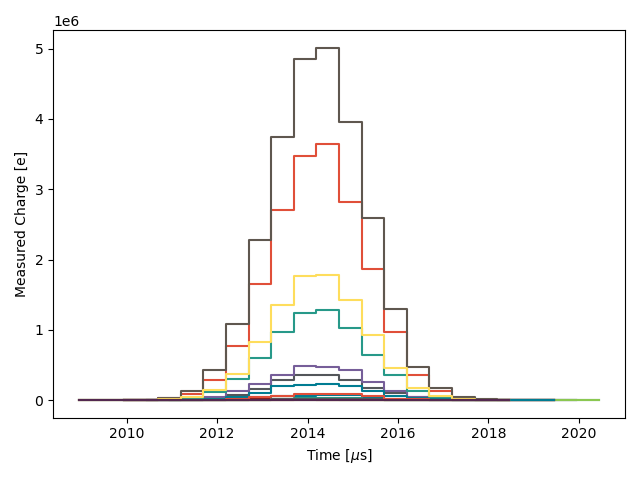

In [10]:
waveform_length = conf.readout_config['coarse_tiles']['integration_length']
dt =  conf.readout_config['coarse_tiles']['clock_interval']
timeticks = pixels['trig t'][:,None] + dt*np.arange(waveform_length)

fig = plt.figure()
plt.step(timeticks.T, pixels['waveform'].T, 
         where = 'mid',
        )
plt.xlabel(r'Time [$\mu$s]')
plt.ylabel(r'Measured Charge [e]')
plt.tight_layout()
plt.show()

When running an analysis loop over many simulated event outputs, we can just use the `OutputParser` object's iterable interface:

In [11]:
for pixels, tiles, meta in op:
    print ("for event", meta['event id'][0])
    print ("found", pixels.shape, "pixel hit(s),")
    print ("and", tiles.shape, "tile hit(s).")

for event 0
found (18,) pixel hit(s),
and (4,) tile hit(s).
for event 1
found (19,) pixel hit(s),
and (2,) tile hit(s).
for event 2
found (18,) pixel hit(s),
and (2,) tile hit(s).
for event 3
found (19,) pixel hit(s),
and (1,) tile hit(s).
for event 4
found (22,) pixel hit(s),
and (2,) tile hit(s).
for event 5
found (22,) pixel hit(s),
and (1,) tile hit(s).
for event 6
found (22,) pixel hit(s),
and (4,) tile hit(s).
for event 7
found (20,) pixel hit(s),
and (1,) tile hit(s).
for event 8
found (20,) pixel hit(s),
and (2,) tile hit(s).
for event 9
found (21,) pixel hit(s),
and (1,) tile hit(s).
